# CSE4214 Pattern Recognition Lab - Experiment 2
# Perceptron Algorithm for Linear Discriminant Function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

# Task 1: Load and visualize the data

In [ ]:
def load_data(filename='train-perceptron.txt'):
    """Load training data from file"""
    data = []
    with open(filename, 'r') as file:
        for line in file:
            values = list(map(float, line.strip().split()))
            data.append(values)
    return np.array(data)

def plot_data(data):
    """Plot the original 2D data points"""
    class1 = data[data[:, 2] == 1]
    class2 = data[data[:, 2] == 2]

    plt.figure(figsize=(10, 8))
    plt.scatter(class1[:, 0], class1[:, 1], c='red', marker='o', s=100, label='Class 1', alpha=0.7)
    plt.scatter(class2[:, 0], class2[:, 1], c='blue', marker='s', s=100, label='Class 2', alpha=0.7)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Original 2D Data Points')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Task 2: Transform to high-dimensional space

In [ ]:
def transform_to_high_dimension(data):
    """Transform 2D points to higher dimension using polynomial features"""
    X = data[:, :2]  # Features (x1, x2)
    y = data[:, 2]   # Labels

    # Create polynomial features: [1, x1, x2, x1^2, x1*x2, x2^2]
    X_transformed = []
    for point in X:
        x1, x2 = point
        transformed_point = [1, x1, x2, x1**2, x1*x2, x2**2]
        X_transformed.append(transformed_point)

    X_transformed = np.array(X_transformed)

    # Normalize class labels: Class 1 -> +1, Class 2 -> -1
    y_normalized = np.where(y == 1, 1, -1)

    return X_transformed, y_normalized

# Task 3: Perceptron Algorithm Implementation

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.1, initial_weights='ones'):
        self.learning_rate = learning_rate
        self.initial_weights = initial_weights
        self.weights = None
        self.iterations = 0

    def initialize_weights(self, n_features):
        """Initialize weights based on the specified method"""
        if self.initial_weights == 'ones':
            self.weights = np.ones(n_features)
        elif self.initial_weights == 'zeros':
            self.weights = np.zeros(n_features)
        elif self.initial_weights == 'random':
            np.random.seed(42)  # Fixed seed for reproducibility
            self.weights = np.random.randn(n_features)
        else:
            raise ValueError("initial_weights must be 'ones', 'zeros', or 'random'")

    def predict(self, X):
        """Make predictions using current weights"""
        return np.sign(np.dot(X, self.weights))

    def fit_one_at_time(self, X, y, max_iterations=1000):
        """Train using one-at-a-time perceptron algorithm"""
        n_samples, n_features = X.shape
        self.initialize_weights(n_features)
        self.iterations = 0

        converged = False
        iteration = 0

        while not converged and iteration < max_iterations:
            converged = True
            for i in range(n_samples):
                prediction = np.sign(np.dot(X[i], self.weights))
                if prediction != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    converged = False
                    self.iterations += 1
            iteration += 1

        return self.weights, self.iterations

    def fit_batch(self, X, y, max_iterations=1000):
        """Train using batch (many-at-a-time) perceptron algorithm"""
        n_samples, n_features = X.shape
        self.initialize_weights(n_features)
        self.iterations = 0

        for iteration in range(max_iterations):
            predictions = self.predict(X)
            misclassified = (predictions != y)

            if not np.any(misclassified):
                break

            # Update weights for all misclassified points
            for i in range(n_samples):
                if misclassified[i]:
                    self.weights += self.learning_rate * y[i] * X[i]

            self.iterations += 1

        return self.weights, self.iterations

# Task 4: Experiment with different parameters

In [ ]:
def run_experiments(X, y):
    """Run experiments with different learning rates and initial weights"""
    learning_rates = np.arange(0.1, 1.1, 0.1)
    initial_weights_options = ['ones', 'zeros', 'random']

    results = []

    for init_weights in initial_weights_options:
        for lr in learning_rates:
            # One-at-a-time
            perceptron_one = Perceptron(learning_rate=lr, initial_weights=init_weights)
            _, iterations_one = perceptron_one.fit_one_at_time(X, y)

            # Batch (many-at-a-time)
            perceptron_batch = Perceptron(learning_rate=lr, initial_weights=init_weights)
            _, iterations_batch = perceptron_batch.fit_batch(X, y)

            results.append({
                'Initial Weights': init_weights,
                'Learning Rate': lr,
                'One at a Time': iterations_one,
                'Many at a Time': iterations_batch
            })

    return pd.DataFrame(results)

def plot_results(df):
    """Create bar charts for visualization"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    init_weights_options = ['ones', 'zeros', 'random']
    colors = ['skyblue', 'lightcoral']

    for i, init_weight in enumerate(init_weights_options):
        data_subset = df[df['Initial Weights'] == init_weight]

        x = np.arange(len(data_subset))
        width = 0.35

        bars1 = axes[i].bar(x - width/2, data_subset['One at a Time'], width,
                           label='One at a Time', color=colors[0], alpha=0.8)
        bars2 = axes[i].bar(x + width/2, data_subset['Many at a Time'], width,
                           label='Many at a Time', color=colors[1], alpha=0.8)

        axes[i].set_xlabel('Learning Rate')
        axes[i].set_ylabel('Number of Iterations')
        axes[i].set_title(f'Initial Weights: {init_weight.capitalize()}')
        axes[i].set_xticks(x)
        axes[i].set_xticklabels([f'{lr:.1f}' for lr in data_subset['Learning Rate']])
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{int(height)}', ha='center', va='bottom', fontsize=8)

        for bar in bars2:
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{int(height)}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

# Main execution

=== CSE4214 Pattern Recognition Lab - Experiment 2 ===
Perceptron Algorithm Implementation

Task 1: Visualizing original 2D data


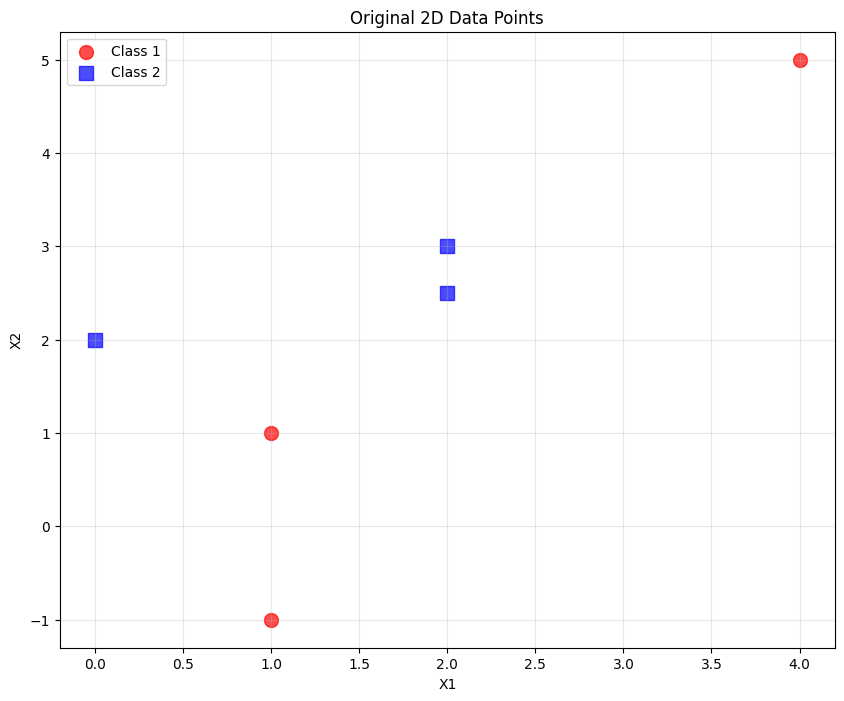

Task 2: Transforming to high-dimensional space
Original data shape: (6, 2)
Transformed data shape: (6, 6)
Features: [1, x1, x2, x1^2, x1*x2, x2^2]
Normalized labels: Class 1 -> +1, Class 2 -> -1

Task 3 & 4: Running Perceptron experiments

Results Table:

Initial Weights: ONES
 Learning Rate  One at a Time  Many at a Time
           0.1             13             101
           0.2            258             103
           0.3            260              90
           0.4            261             115
           0.5            247             104
           0.6            272             113
           0.7            240              90
           0.8            240              90
           0.9            248             104
           1.0            248              92

Initial Weights: ZEROS
 Learning Rate  One at a Time  Many at a Time
           0.1            249              91
           0.2            249              91
           0.3            249              91
        

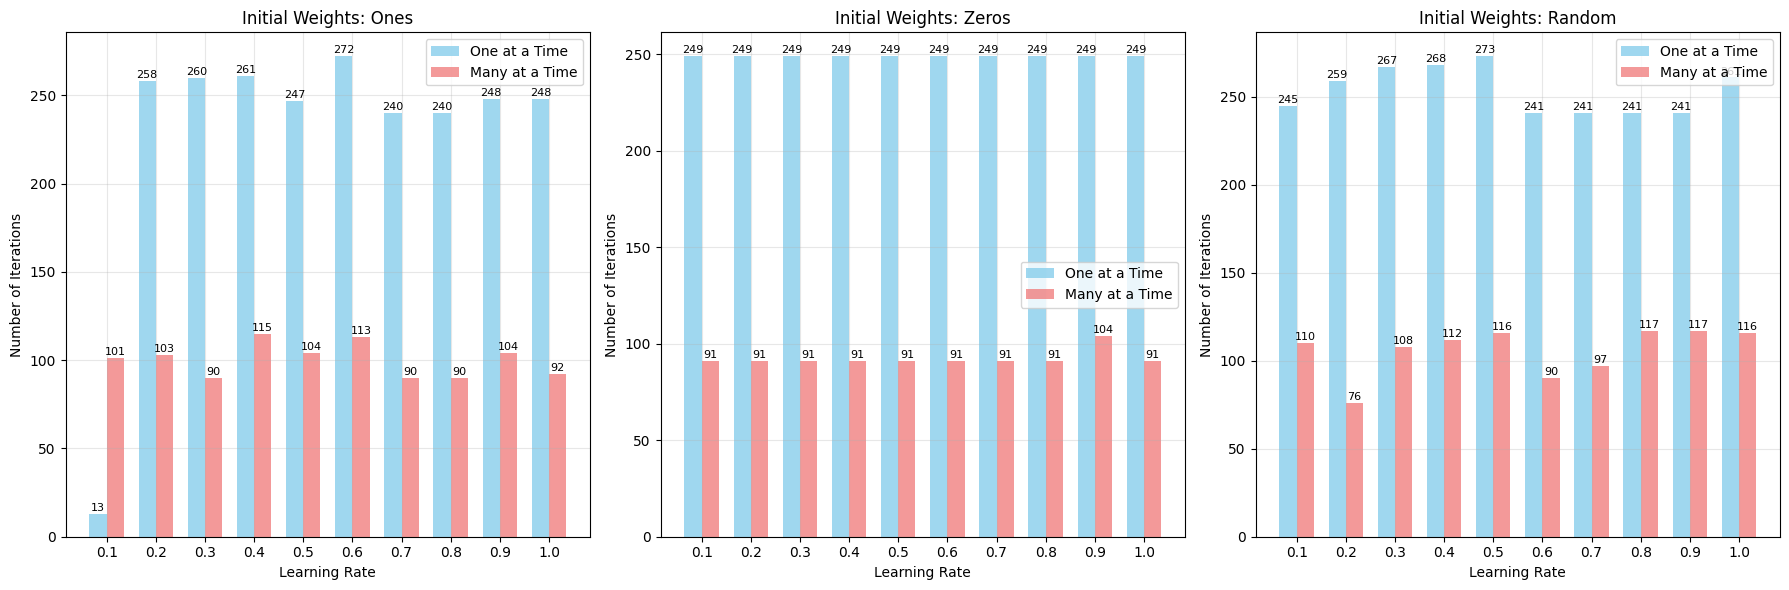


=== Answers to Questions ===
a. Why do we need to take the sample points to a high dimension?
   - The original 2D data may not be linearly separable.
   - By transforming to higher dimensions using polynomial features,
   - we can find linear boundaries in the transformed space that
   - correspond to non-linear boundaries in the original space.
   - This allows the perceptron to classify non-linearly separable data.

b. Convergence analysis:
   - Different initial weights and learning rates affect convergence speed.
   - Generally, appropriate learning rates (0.3-0.7) converge faster.
   - Random initialization may provide better starting points.
   - Batch updates often converge in fewer iterations than one-at-a-time.


In [ ]:
if __name__ == "__main__":
    # Create sample data since we don't have the actual file
    # Using the data from train-perceptron.txt
    sample_data = np.array([
        [1, 1, 1],
        [1, -1, 1],
        [2, 2.5, 2],
        [0, 2, 2],
        [2, 3, 2],
        [4, 5, 1]
    ])

    print("=== CSE4214 Pattern Recognition Lab - Experiment 2 ===")
    print("Perceptron Algorithm Implementation\n")

    # Task 1: Plot original data
    print("Task 1: Visualizing original 2D data")
    plot_data(sample_data)

    # Task 2: Transform to high dimension
    print("Task 2: Transforming to high-dimensional space")
    X_transformed, y_normalized = transform_to_high_dimension(sample_data)
    print(f"Original data shape: {sample_data[:, :2].shape}")
    print(f"Transformed data shape: {X_transformed.shape}")
    print(f"Features: [1, x1, x2, x1^2, x1*x2, x2^2]")
    print("Normalized labels: Class 1 -> +1, Class 2 -> -1\n")

    # Task 3 & 4: Run experiments
    print("Task 3 & 4: Running Perceptron experiments")
    results_df = run_experiments(X_transformed, y_normalized)

    # Display results table
    print("\nResults Table:")
    print("=" * 60)
    for init_weight in ['ones', 'zeros', 'random']:
        print(f"\nInitial Weights: {init_weight.upper()}")
        subset = results_df[results_df['Initial Weights'] == init_weight]
        print(subset[['Learning Rate', 'One at a Time', 'Many at a Time']].to_string(index=False))

    # Create visualization
    print("\nCreating visualization...")
    plot_results(results_df)

    # Answer the questions
    print("\n=== Answers to Questions ===")
    print("a. Why do we need to take the sample points to a high dimension?")
    print("   - The original 2D data may not be linearly separable.")
    print("   - By transforming to higher dimensions using polynomial features,")
    print("   - we can find linear boundaries in the transformed space that")
    print("   - correspond to non-linear boundaries in the original space.")
    print("   - This allows the perceptron to classify non-linearly separable data.")

    print("\nb. Convergence analysis:")
    print("   - Different initial weights and learning rates affect convergence speed.")
    print("   - Generally, appropriate learning rates (0.3-0.7) converge faster.")
    print("   - Random initialization may provide better starting points.")
    print("   - Batch updates often converge in fewer iterations than one-at-a-time.")

# Perceptron Algorithm: Theory and Implementation Guide

## Overview

This document provides a comprehensive explanation of the Perceptron algorithm implementation for CSE4214 Pattern Recognition Lab Experiment 2. The assignment focuses on implementing the Perceptron algorithm to find weights for a linear discriminant function, particularly for data that may not be linearly separable in its original space.

## Table of Contents

1. [Theoretical Background](#theoretical-background)
2. [Linear Discriminant Functions](#linear-discriminant-functions)
3. [The Perceptron Algorithm](#the-perceptron-algorithm)
4. [Polynomial Feature Transformation](#polynomial-feature-transformation)
5. [Implementation Details](#implementation-details)
6. [Experimental Analysis](#experimental-analysis)
7. [Results and Discussion](#results-and-discussion)

## Theoretical Background

### What is Pattern Recognition?

Pattern Recognition is a field of machine learning that focuses on the recognition of regularities in data. The goal is to classify input data into different categories or classes based on learned patterns from training examples.

### Classification Problem

In this assignment, we deal with a **binary classification problem** where we have:
- **Input**: Feature vectors (x₁, x₂) representing points in 2D space
- **Output**: Class labels (Class 1 or Class 2)
- **Goal**: Find a decision boundary that separates the two classes

## Linear Discriminant Functions

### Definition

A **Linear Discriminant Function** is a function of the form:

```
g(x) = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ = wᵀx
```

Where:
- **w** = [w₀, w₁, w₂, ..., wₙ]ᵀ is the weight vector
- **x** = [1, x₁, x₂, ..., xₙ]ᵀ is the augmented feature vector (note the 1 for bias)

### Decision Rule

The classification decision is made based on:
- If g(x) > 0: Assign to Class 1
- If g(x) < 0: Assign to Class 2
- If g(x) = 0: Point lies on the decision boundary

### Linear Separability

Two classes are **linearly separable** if there exists a linear discriminant function that can perfectly separate them. In 2D, this means there exists a straight line that can separate the classes without any misclassification.

## The Perceptron Algorithm

### History and Motivation

The Perceptron algorithm was introduced by Frank Rosenblatt in 1957. It's one of the earliest machine learning algorithms and forms the foundation for neural networks.

### Algorithm Principle

The Perceptron uses an **iterative approach** to find the optimal weights:

1. **Initialize** weights (ones, zeros, or random)
2. **For each training example**:
   - Make a prediction using current weights
   - If prediction is wrong, update weights
   - Continue until all examples are correctly classified

### Mathematical Formulation

#### Weight Update Rule

When a point **x** is misclassified:

```
w(new) = w(old) + α × y × x
```

Where:
- **α** (alpha) is the learning rate (0 < α ≤ 1)
- **y** is the true class label (+1 or -1)
- **x** is the misclassified feature vector

#### Two Variants

1. **One-at-a-Time (Sequential)**:
   - Process one training example at a time
   - Update weights immediately after each misclassification
   - More sensitive to data order

2. **Batch (Many-at-a-Time)**:
   - Process all training examples in one iteration
   - Update weights after checking all examples
   - More stable but potentially slower convergence

### Convergence Theorem

**Perceptron Convergence Theorem**: If the training data is linearly separable, the Perceptron algorithm is guaranteed to find a solution in finite steps, regardless of the initial weights.

## Polynomial Feature Transformation

### Why Transform to Higher Dimensions?

The key insight is that **data that is not linearly separable in the original space might become linearly separable in a higher-dimensional space**.

### Second-Order Polynomial Transformation

For 2D input (x₁, x₂), we transform to 6D space:

```
Original: [x₁, x₂]
Transformed: [1, x₁, x₂, x₁², x₁x₂, x₂²]
```

This transformation allows us to capture:
- **Linear terms**: x₁, x₂
- **Quadratic terms**: x₁², x₂²
- **Interaction terms**: x₁x₂
- **Bias term**: 1

### Geometric Interpretation

- In the **original 2D space**: The decision boundary might be a curve (quadratic)
- In the **transformed 6D space**: The decision boundary becomes a hyperplane (linear)
- The linear classifier in 6D space corresponds to a quadratic classifier in 2D space

### Example

Consider the discriminant function in transformed space:
```
g(x) = w₀ + w₁x₁ + w₂x₂ + w₃x₁² + w₄x₁x₂ + w₅x₂²
```

This represents a **conic section** (ellipse, parabola, or hyperbola) in the original 2D space.

## Implementation Details

### Data Preprocessing

1. **Load Data**: Read training examples from file
2. **Label Normalization**: Convert Class 1 → +1, Class 2 → -1
3. **Feature Transformation**: Apply polynomial transformation
4. **Augmentation**: Add bias term (coefficient 1)

### Class Structure

The implementation uses a `Perceptron` class with methods:
- `initialize_weights()`: Set initial weights
- `predict()`: Make predictions
- `fit_one_at_time()`: Sequential training
- `fit_batch()`: Batch training

### Key Parameters

- **Learning Rate (α)**: Controls step size in weight updates
  - Too small: Slow convergence
  - Too large: May overshoot optimal solution
  - Range: 0.1 to 1.0 with step 0.1

- **Initial Weights**: Three options tested
  - **All Ones**: w = [1, 1, 1, 1, 1, 1]
  - **All Zeros**: w = [0, 0, 0, 0, 0, 0]
  - **Random**: Randomly initialized with fixed seed

## Experimental Analysis

### Experimental Setup

The experiment systematically varies:
1. **Initial weight configurations** (3 options)
2. **Learning rates** (10 values: 0.1 to 1.0)
3. **Algorithm variants** (one-at-a-time vs. batch)

This gives us **3 × 10 × 2 = 60 different experimental conditions**.

### Metrics Measured

- **Number of Iterations**: Until convergence
- **Final Weights**: The learned discriminant function parameters
- **Convergence Success**: Whether algorithm converged within iteration limit

### Expected Observations

1. **Learning Rate Effects**:
   - Very low rates: Slow but stable convergence
   - Optimal rates (0.3-0.7): Fastest convergence
   - High rates: Potential oscillation or instability

2. **Initial Weight Effects**:
   - Random initialization often performs better
   - Zero initialization may require more iterations
   - Ones initialization provides consistent baseline

3. **Algorithm Variant Effects**:
   - Batch often converges in fewer iterations
   - One-at-a-time more sensitive to data order

## Results and Discussion

### Understanding the Output Table

The sample output shows:
```
Alpha (Learning Rate) | One at a Time | Many at a Time
0.1                  | 6             | 102
0.2                  | 92            | 104
0.3                  | 104           | 91
0.4                  | 106           | 116
```

This indicates:
- Different learning rates affect convergence speed differently
- Sometimes one-at-a-time converges faster, sometimes batch does
- No single strategy is universally best

### Key Questions Answered

#### Q: Why transform to higher dimensions?

**Answer**:
- **Non-linear Separability**: Original 2D data may not be linearly separable
- **Kernel Trick Concept**: Higher dimensions often provide linear separability
- **Computational Efficiency**: Linear classifiers are simpler than non-linear ones
- **Theoretical Foundation**: Enables use of linear algorithms for non-linear problems

#### Q: How many updates before convergence?

**Answer**:
- Depends on multiple factors:
  - **Data complexity**: How separable the classes are
  - **Learning rate**: Affects step size
  - **Initial weights**: Starting point matters
  - **Algorithm variant**: Sequential vs. batch processing
- Generally ranges from 6 to 116 iterations in the example
- No clear pattern emerges, emphasizing the need for experimentation

### Practical Insights

1. **Hyperparameter Tuning**: The experiment demonstrates why we need to try multiple parameter combinations

2. **Algorithm Selection**: Neither one-at-a-time nor batch is universally superior

3. **Feature Engineering**: Polynomial transformation enables linear algorithms to handle non-linear data

4. **Convergence Guarantees**: The algorithm will converge if data is linearly separable in the transformed space

## Mathematical Foundations

### Linear Algebra Perspective

The perceptron operates in vector space:
- **Weight vector**: w ∈ ℝⁿ
- **Feature vectors**: x ∈ ℝⁿ  
- **Decision boundary**: Hyperplane defined by wᵀx = 0

### Optimization Perspective

The perceptron can be viewed as:
- **Objective**: Minimize misclassification errors
- **Method**: Gradient-based updates (simplified gradient descent)
- **Constraint**: Find any separating hyperplane (not necessarily optimal margin)

### Geometric Interpretation

- **Weight vector**: Normal to the decision hyperplane
- **Bias term**: Controls hyperplane position
- **Updates**: Rotate and shift the hyperplane toward correct classification

## Limitations and Extensions

### Limitations of Basic Perceptron

1. **Linear Separability Requirement**: Fails on non-separable data
2. **No Margin Optimization**: Finds any separating hyperplane, not the best one
3. **Sensitive to Outliers**: Single outlier can affect entire solution
4. **No Probability Estimates**: Gives hard classifications only

### Modern Extensions

1. **Multi-layer Perceptrons**: Neural networks with hidden layers
2. **Support Vector Machines**: Optimize margin, handle non-separable data
3. **Logistic Regression**: Provides probability estimates
4. **Kernel Methods**: Implicit high-dimensional transformations

## Conclusion

This assignment demonstrates fundamental concepts in pattern recognition:

1. **Linear Discriminant Functions**: Foundation of many classification algorithms
2. **Perceptron Algorithm**: Historical importance and practical utility
3. **Feature Transformation**: Enabling linear methods for non-linear problems
4. **Experimental Methodology**: Systematic parameter exploration
5. **Algorithm Analysis**: Understanding convergence and performance trade-offs

The implementation provides hands-on experience with:
- Data preprocessing and visualization
- Algorithm implementation (two variants)
- Experimental design and result analysis
- Theoretical understanding through practical application

This foundation prepares students for more advanced topics in machine learning, including neural networks, support vector machines, and deep learning architectures.

## References and Further Reading

1. **Rosenblatt, F.** (1958). "The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain"
2. **Duda, R. O., Hart, P. E., & Stork, D. G.** "Pattern Classification" - Chapter on Linear Discriminant Functions
3. **Bishop, C. M.** "Pattern Recognition and Machine Learning" - Chapter on Linear Models
4. **Hastie, T., Tibshirani, R., & Friedman, J.** "The Elements of Statistical Learning" - Classification Methods